### 05_evaluation.ipynb

[Purpose]
- Visualize multi-model comparison
- Generate comprehensive charts
- Create final report

[Input]
- Trained models from models/
- Comparison results from outputs/reports/

[Output]
- Comparison charts in outputs/figures/
- Final report markdown

In [ ]:
# ===========================================
# Cell 1: Google Drive Mount
# ===========================================
from google.colab import drive

drive.mount('/content/drive')
print("Drive mount done!")

In [ ]:
# ===========================================
# Cell 2: Config Load + Path Setup
# ===========================================
import os
import yaml

CONFIG_PATH = "/content/config.yaml"

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

DRIVE_ROOT = f"/content/drive/MyDrive/{config['project_name']}"
PROCESSED_DATA_PATH = os.path.join(DRIVE_ROOT, config['paths']['processed_data'])
MODEL_PATH = os.path.join(DRIVE_ROOT, "models")
REPORT_PATH = os.path.join(DRIVE_ROOT, "outputs", "reports")
FIGURE_PATH = os.path.join(DRIVE_ROOT, "outputs", "figures")

os.makedirs(FIGURE_PATH, exist_ok=True)

print(f"Project: {config['project_name']}")

In [ ]:
# ===========================================
# Cell 3: Library Import + Font Setup
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('dark_background')

# Custom color palette for dark mode
COLORS = ['#00BFFF', '#FF6B6B', '#98FB98', '#DDA0DD', '#FFD700']

print("Library + Font setup done!")

In [ ]:
# ===========================================
# Cell 4: Load Results
# ===========================================
# Load comparison results
json_path = os.path.join(REPORT_PATH, "model_comparison_results.json")
with open(json_path, 'r') as f:
    comparison_results = json.load(f)

# Load metrics CSV
csv_path = os.path.join(REPORT_PATH, "model_comparison_metrics.csv")
results_df = pd.read_csv(csv_path)

# Load feature importance
importance_path = os.path.join(REPORT_PATH, "feature_importance_comparison.csv")
importance_df = pd.read_csv(importance_path)

print("Results loaded!")
print(results_df)

In [ ]:
# ===========================================
# Cell 5: Visualization - Model Comparison Bar Chart
# ===========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, color='white')

metrics = ['rmse', 'mae', 'r2', 'mape']
titles = ['RMSE (lower is better)', 'MAE (lower is better)',
          'R² (higher is better)', 'MAPE % (lower is better)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]

    bars = ax.bar(results_df['model'], results_df[metric], color=COLORS[:len(results_df)])
    ax.set_title(title, fontsize=12, color='white')
    ax.set_ylabel(metric.upper(), fontsize=10, color='white')
    ax.tick_params(colors='white')

    # Add value labels
    for bar, val in zip(bars, results_df[metric]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}' if metric != 'mape' else f'{val:.2f}%',
                ha='center', va='bottom', fontsize=9, color='white')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'model_comparison_metrics.png'),
            dpi=150, facecolor='#1e1e1e', bbox_inches='tight')
plt.show()

print("Saved: model_comparison_metrics.png")

In [ ]:
# ===========================================
# Cell 6: Visualization - Training Time Comparison
# ===========================================
plt.figure(figsize=(10, 6))

bars = plt.bar(results_df['model'], results_df['train_time'], color=COLORS[:len(results_df)])
plt.title('Training Time Comparison', fontsize=14, color='white')
plt.ylabel('Time (seconds)', fontsize=12, color='white')
plt.xlabel('Model', fontsize=12, color='white')

for bar, val in zip(bars, results_df['train_time']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{val:.2f}s', ha='center', va='bottom', fontsize=10, color='white')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'training_time_comparison.png'),
            dpi=150, facecolor='#1e1e1e')
plt.show()

print("Saved: training_time_comparison.png")


In [ ]:
# ===========================================
# Cell 7: Visualization - Feature Importance Heatmap
# ===========================================
plt.figure(figsize=(12, 6))

# Normalize importance for comparison
importance_norm = importance_df.copy()
for col in ['LightGBM', 'XGBoost', 'RandomForest', 'CatBoost']:
    importance_norm[col] = importance_norm[col] / importance_norm[col].sum() * 100

importance_matrix = importance_norm.set_index('feature')[['LightGBM', 'XGBoost', 'RandomForest', 'CatBoost']]

sns.heatmap(importance_matrix, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Importance (%)'})
plt.title('Feature Importance Comparison (Normalized %)', fontsize=14, color='white')
plt.xlabel('Model', fontsize=12, color='white')
plt.ylabel('Feature', fontsize=12, color='white')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'feature_importance_heatmap.png'),
            dpi=150, facecolor='#1e1e1e')
plt.show()

print("Saved: feature_importance_heatmap.png")

In [ ]:
# ===========================================
# Cell 8: Visualization - Feature Importance Bar Chart
# ===========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Importance by Model', fontsize=16, color='white')

models = ['LightGBM', 'XGBoost', 'RandomForest', 'CatBoost']

for idx, model in enumerate(models):
    ax = axes[idx // 2, idx % 2]

    sorted_df = importance_df.sort_values(model, ascending=True)
    ax.barh(sorted_df['feature'], sorted_df[model], color=COLORS[idx])
    ax.set_title(model, fontsize=12, color='white')
    ax.set_xlabel('Importance', fontsize=10, color='white')
    ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'feature_importance_by_model.png'),
            dpi=150, facecolor='#1e1e1e', bbox_inches='tight')
plt.show()

print("Saved: feature_importance_by_model.png")

In [ ]:
# ===========================================
# Cell 9: Load Models and Generate Predictions
# ===========================================
# Load test data
parquet_path = os.path.join(PROCESSED_DATA_PATH, "instance_usage_full_processed.parquet")
csv_path_data = os.path.join(PROCESSED_DATA_PATH, "instance_usage_processed.csv")

if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
else:
    df = pd.read_csv(csv_path_data)

features = ['cpu', 'memory', 'duration', 'hour']
target = 'energy_kwh'

X = df[features]
y = df[target]

from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load models and predict
predictions = {}
model_files = {
    'LightGBM': 'energy_model_lightgbm.pkl',
    'XGBoost': 'energy_model_xgboost.pkl',
    'RandomForest': 'energy_model_randomforest.pkl',
    'CatBoost': 'energy_model_catboost.pkl'
}

for name, file in model_files.items():
    model_path = os.path.join(MODEL_PATH, file)
    if os.path.exists(model_path):
        with open(model_path, 'rb') as f:
            model = pickle.load(f)
        predictions[name] = model.predict(X_test)
        print(f"Loaded: {name}")

In [ ]:
# ===========================================
# Cell 10: Visualization - Actual vs Predicted (All Models)
# ===========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Actual vs Predicted - All Models', fontsize=16, color='white')

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx // 2, idx % 2]

    # Sample for visualization (too many points = slow)
    sample_size = min(5000, len(y_test))
    sample_idx = np.random.choice(len(y_test), sample_size, replace=False)

    ax.scatter(y_test.iloc[sample_idx], y_pred[sample_idx],
               alpha=0.3, s=5, color=COLORS[idx])

    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    ax.set_title(f'{name}', fontsize=12, color='white')
    ax.set_xlabel('Actual (kWh)', fontsize=10, color='white')
    ax.set_ylabel('Predicted (kWh)', fontsize=10, color='white')
    ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'actual_vs_predicted_all_models.png'),
            dpi=150, facecolor='#1e1e1e', bbox_inches='tight')
plt.show()

print("Saved: actual_vs_predicted_all_models.png")

In [ ]:
# ===========================================
# Cell 11: Visualization - Error Distribution (All Models)
# ===========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Prediction Error Distribution - All Models', fontsize=16, color='white')

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx // 2, idx % 2]

    errors = y_pred - y_test.values

    ax.hist(errors, bins=50, color=COLORS[idx], alpha=0.7, edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', lw=2)
    ax.set_title(f'{name}', fontsize=12, color='white')
    ax.set_xlabel('Error (kWh)', fontsize=10, color='white')
    ax.set_ylabel('Count', fontsize=10, color='white')
    ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'error_distribution_all_models.png'),
            dpi=150, facecolor='#1e1e1e', bbox_inches='tight')
plt.show()

print("Saved: error_distribution_all_models.png")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mount done!
Project: EcoTracing
Library + Font setup done!
Results loaded!
          model      rmse       mae        r2      mape  train_time
0  RandomForest  0.000014  0.000008  0.999995  0.066324  469.778683
1      LightGBM  0.000034  0.000004  0.999970  0.151962   41.609147
2      CatBoost  0.000043  0.000010  0.999953  0.789135   77.644377
3       XGBoost  0.000057  0.000019  0.999918  2.782808   65.597324


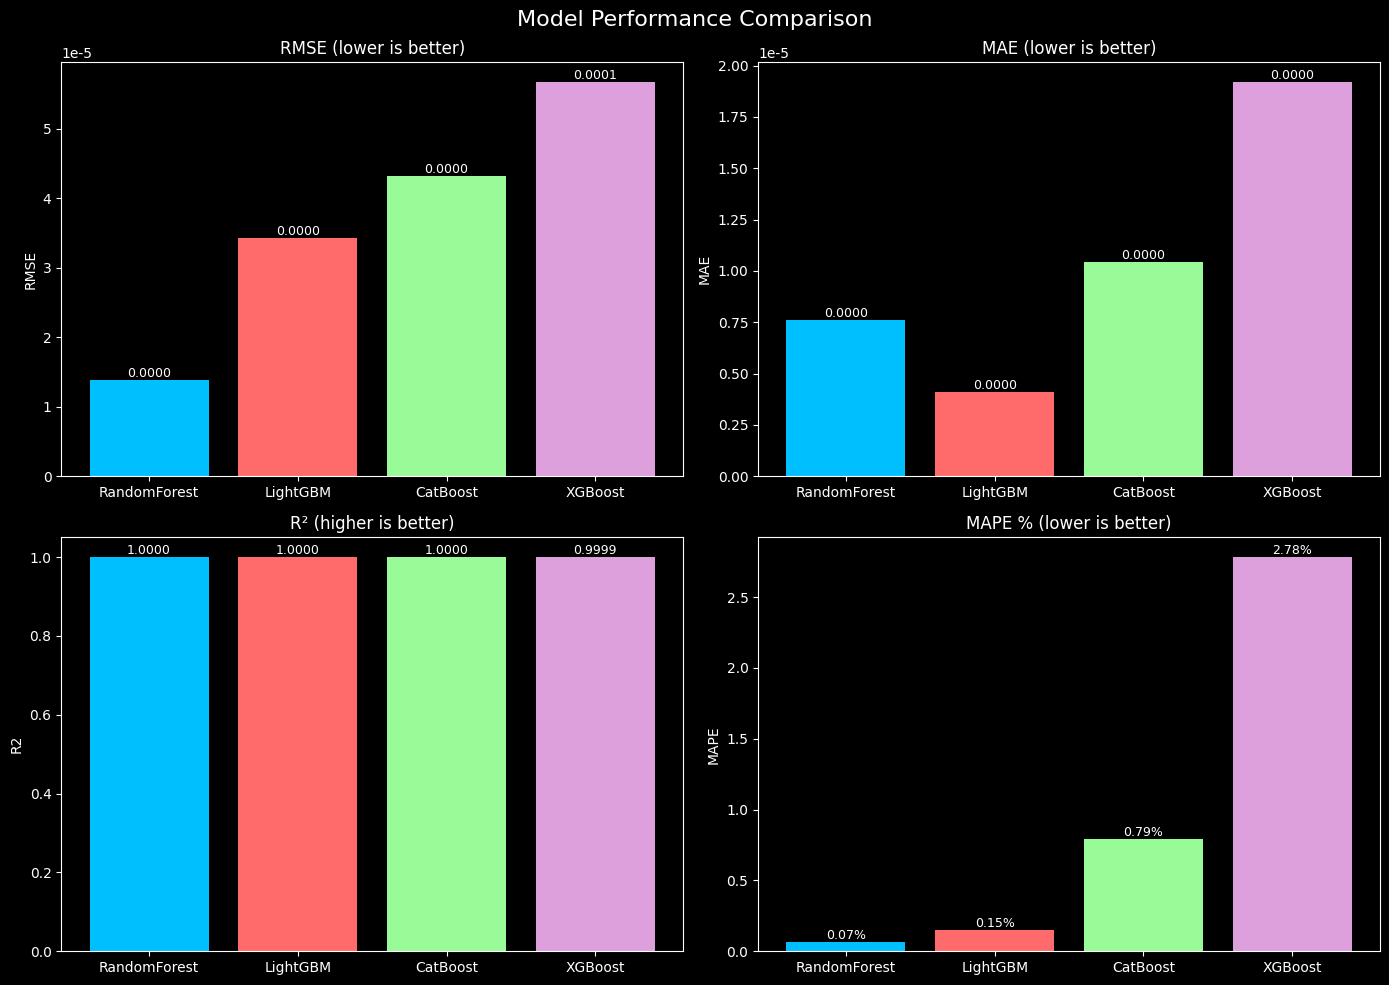

Saved: model_comparison_metrics.png


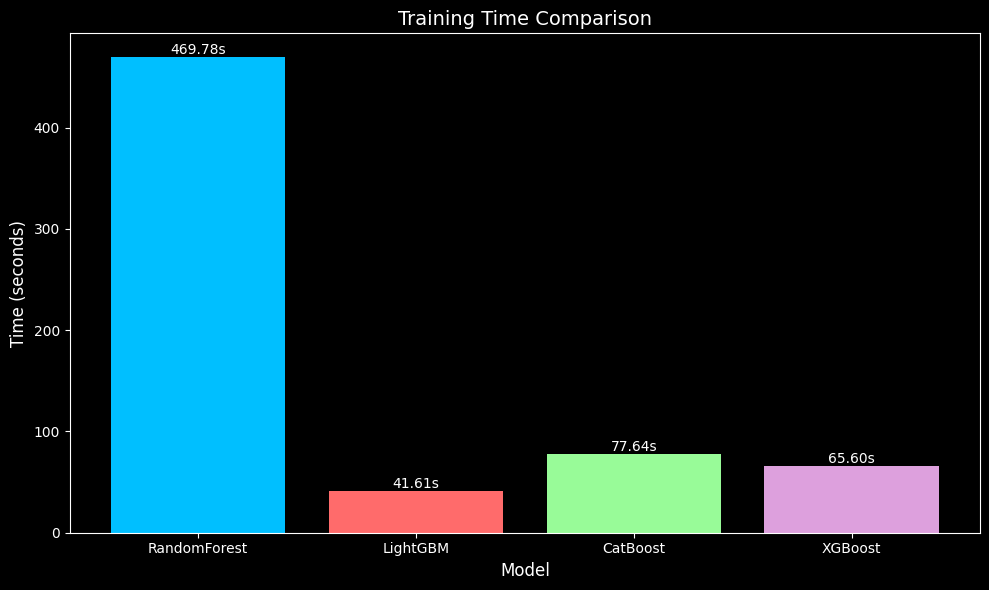

Saved: training_time_comparison.png


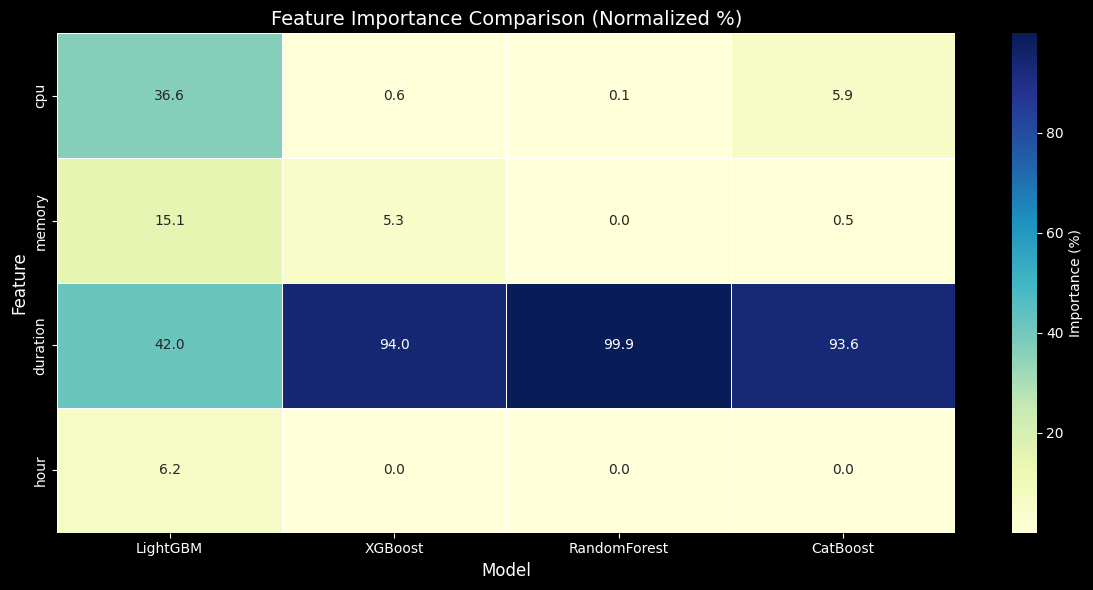

Saved: feature_importance_heatmap.png


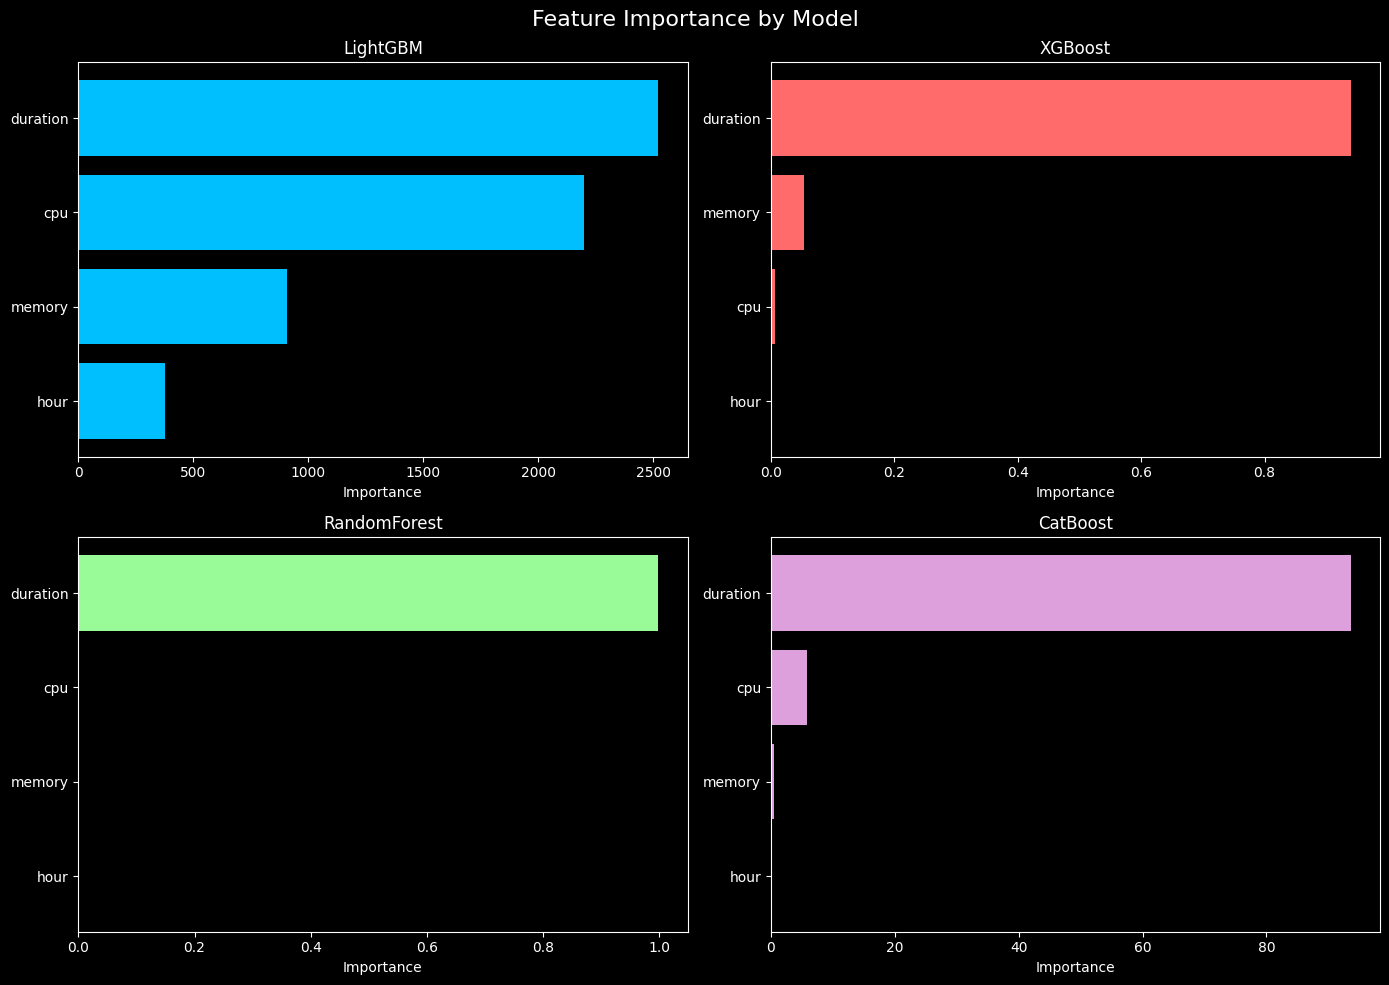

Saved: feature_importance_by_model.png
Loaded: LightGBM
Loaded: XGBoost
Loaded: RandomForest
Loaded: CatBoost


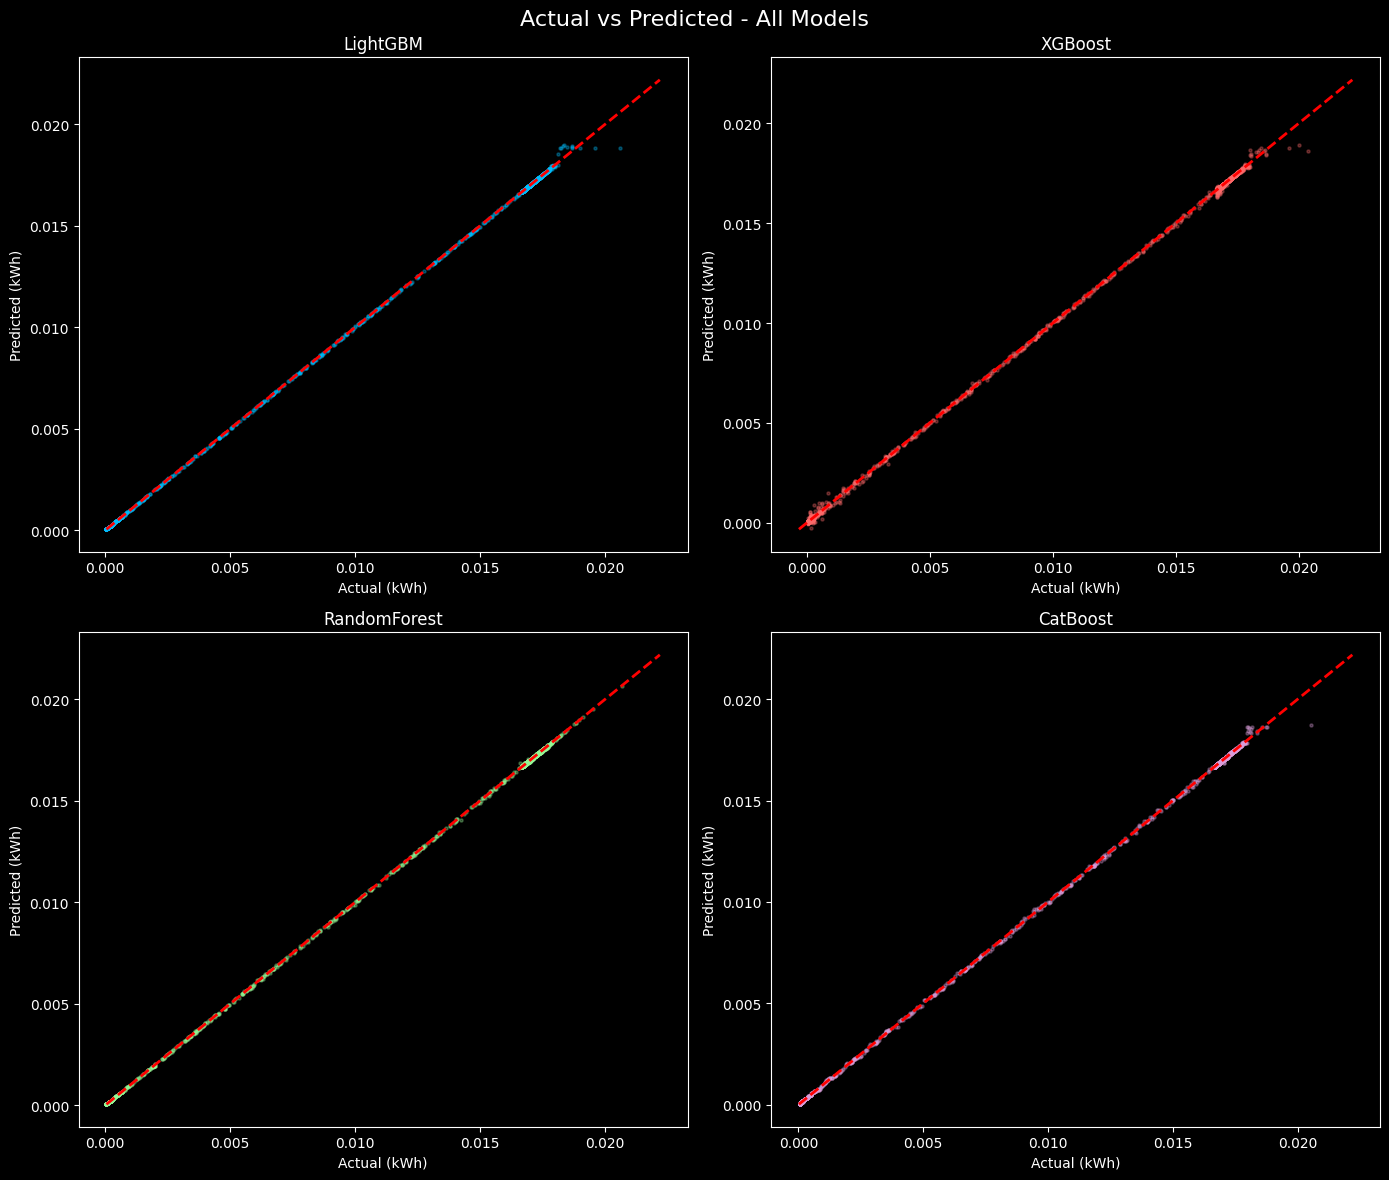

Saved: actual_vs_predicted_all_models.png


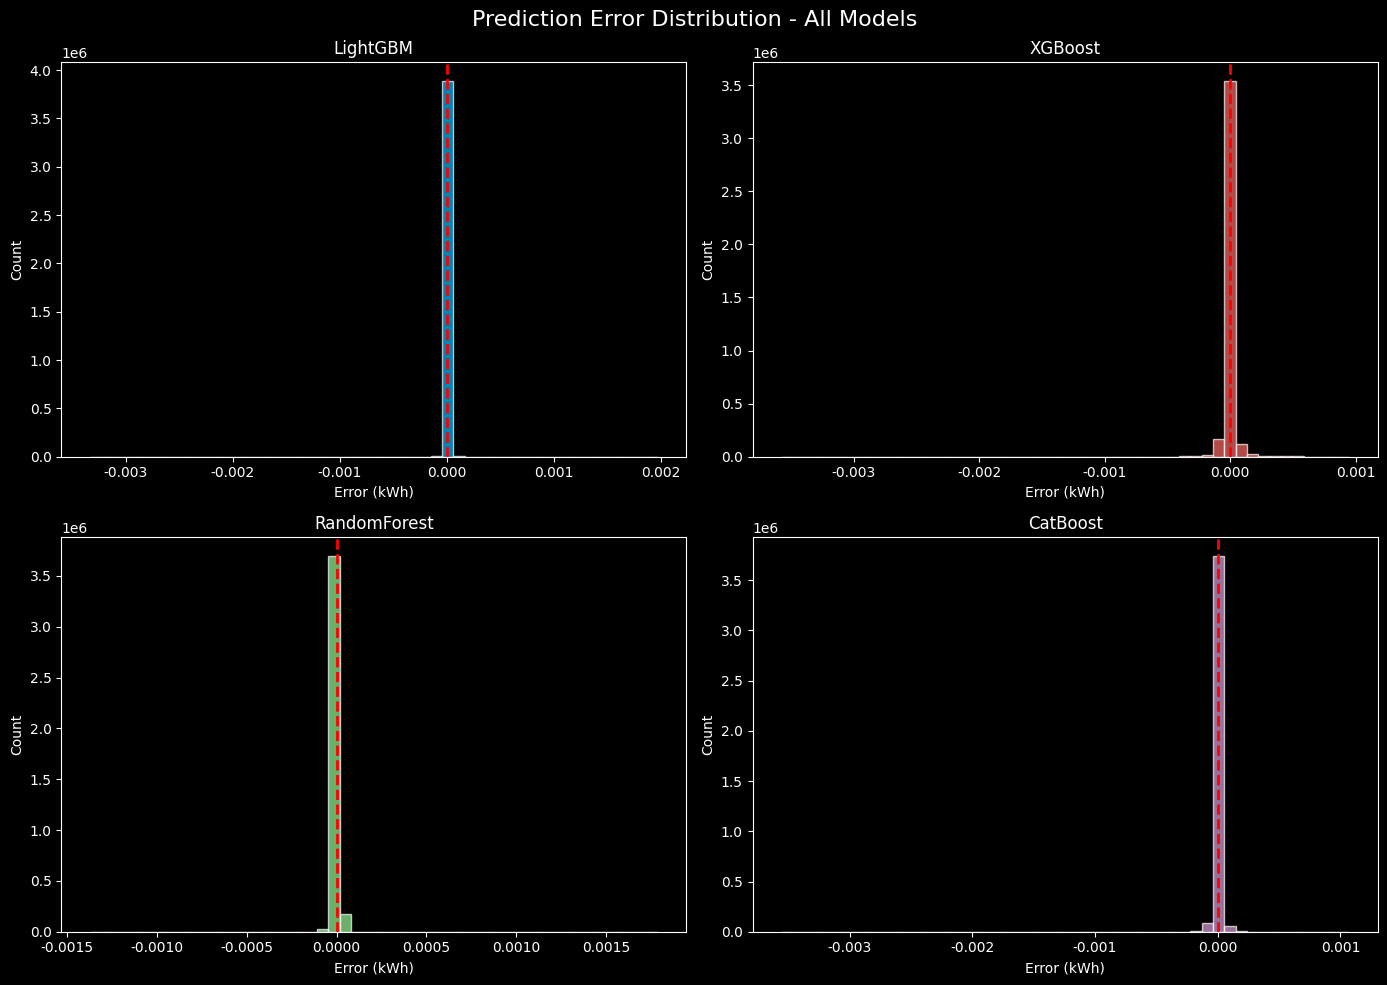

Saved: error_distribution_all_models.png
Saved: /content/drive/MyDrive/EcoTracing/outputs/reports/phase1_full_results.json
PHASE 1 COMPLETE: Multi-Model Energy Prediction

[Dataset]
  Total samples: 19,523,808
  Train: 15,619,046
  Test: 3,904,762

[Model Performance]
  LightGBM    : RMSE=0.000034, R2=0.999970
  XGBoost     : RMSE=0.000057, R2=0.999918
  RandomForest: RMSE=0.000014, R2=0.999995
  CatBoost    : RMSE=0.000043, R2=0.999953

[Best Model]
  RandomForest

[Generated Figures]
  - model_comparison_metrics.png
  - training_time_comparison.png
  - feature_importance_heatmap.png
  - feature_importance_by_model.png
  - actual_vs_predicted_all_models.png
  - error_distribution_all_models.png

[Next Step]
  Phase 2: Energy -> Carbon Emission Conversion


In [ ]:
# ===========================================
# Cell 12: Save Final Results to Drive
# ===========================================
final_results = {
    'model': 'Multi-Model Comparison',
    'dataset': comparison_results['dataset'],
    'samples': comparison_results['samples'],
    'features': comparison_results['features'],
    'target': comparison_results['target'],
    'best_model': comparison_results['best_model'],
    'models': comparison_results['models'],
    'figures': [
        'model_comparison_metrics.png',
        'training_time_comparison.png',
        'feature_importance_heatmap.png',
        'feature_importance_by_model.png',
        'actual_vs_predicted_all_models.png',
        'error_distribution_all_models.png'
    ]
}

final_path = os.path.join(REPORT_PATH, "phase1_full_results.json")
with open(final_path, 'w', encoding='utf-8') as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False)

print(f"Saved: {final_path}")


# ===========================================
# Cell 13: Summary Report
# ===========================================
print("=" * 60)
print("PHASE 1 COMPLETE: Multi-Model Energy Prediction")
print("=" * 60)

print(f"\n[Dataset]")
print(f"  Total samples: {comparison_results['samples']['total']:,}")
print(f"  Train: {comparison_results['samples']['train']:,}")
print(f"  Test: {comparison_results['samples']['test']:,}")

print(f"\n[Model Performance]")
for model in comparison_results['models']:
    print(f"  {model['model']:12s}: RMSE={model['rmse']:.6f}, R2={model['r2']:.6f}")

print(f"\n[Best Model]")
print(f"  {comparison_results['best_model']}")

print(f"\n[Generated Figures]")
for fig in final_results['figures']:
    print(f"  - {fig}")

print(f"\n[Next Step]")
print(f"  Phase 2: Energy -> Carbon Emission Conversion")